In [1]:
import mygene
import pandas as pd

In [2]:
# Instantiate the query client
mg = mygene.MyGeneInfo()

In [3]:
loops_with_entrezid=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/loops_with_gene_info_genelevel_auxincpi.csv", sep=",")
loops_with_entrezid

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.024018,0.5773,0.0494,NaN,NaN,NaN,NaN,NaN,NaN,85452
1,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.024769,0.6002,0.0948,NaN,NaN,NaN,NaN,NaN,NaN,1953
2,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.042592,0.5949,0.0842,NaN,NaN,NaN,NaN,NaN,NaN,1953
3,5,chr1,3912500,3917500,chr1,4822500,4827500,shared,0.006495,0.007785,...,0.035901,0.5098,0.1020,0.422638,0.450561,-0.182794,-0.090802,0.027922,0.091992,100133612
4,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,26038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19818,32255,chrX,38452500,38457500,chrX,38652500,38657500,gained,0.012273,0.017362,...,0.027401,0.3817,0.0474,-1.192141,-1.204536,-0.019207,-0.057847,-0.012394,-0.038640,7102
19819,32256,chrX,46202500,46207500,chrX,46322500,46327500,gained,0.012588,0.030242,...,0.043071,0.4335,0.0058,0.221901,0.422413,0.402623,0.416201,0.200512,0.013579,101927574
19820,32257,chrX,46902500,46907500,chrX,47092500,47097500,gained,0.016321,0.021143,...,0.037889,0.3925,0.0382,0.075883,0.096014,0.251793,0.350638,0.020132,0.098845,9104
19821,32260,chrX,101592500,101597500,chrX,101792500,101797500,gained,0.019086,0.025339,...,0.044260,0.4002,0.1120,0.074520,-0.061493,0.270996,0.177009,-0.136014,-0.093987,54470


In [4]:
# Step 1: Expand multiple gene IDs
split_ids = loops_with_entrezid['gene_id'].dropna().astype(str).str.split(',')

# Step 2: Flatten and keep only numeric values
flat_ids = [i.strip() for sublist in split_ids for i in sublist if i.strip().isdigit()]
unique_entrez_ids = list(set(flat_ids))

# Step 3: Query MyGene.info
results = mg.querymany(unique_entrez_ids, scopes='entrezgene', fields='symbol', species='human')

# Step 4: Build mapping dictionary
entrez_to_symbol = {r['query']: r.get('symbol', None) for r in results}

# Step 5: Map gene symbols (handling multi-ID rows)
def map_ids_to_symbols(gene_id_str):
    if pd.isna(gene_id_str):
        return None
    ids = gene_id_str.split(',')
    symbols = [entrez_to_symbol.get(i.strip()) for i in ids if i.strip() in entrez_to_symbol]
    return ','.join(sorted(set(filter(None, symbols)))) if symbols else None

# Step 6: Apply to your DataFrame
loops_with_entrezid['gene_symbol'] = loops_with_entrezid['gene_id'].astype(str).apply(map_ids_to_symbols)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


2 input query terms found no hit:	['3', '103021294']


In [5]:
loops_with_entrezid

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.5773,0.0494,NaN,NaN,NaN,NaN,NaN,NaN,85452,CFAP74
1,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.6002,0.0948,NaN,NaN,NaN,NaN,NaN,NaN,1953,MEGF6
2,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.5949,0.0842,NaN,NaN,NaN,NaN,NaN,NaN,1953,MEGF6
3,5,chr1,3912500,3917500,chr1,4822500,4827500,shared,0.006495,0.007785,...,0.5098,0.1020,0.422638,0.450561,-0.182794,-0.090802,0.027922,0.091992,100133612,LINC01134
4,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,26038,CHD5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19818,32255,chrX,38452500,38457500,chrX,38652500,38657500,gained,0.012273,0.017362,...,0.3817,0.0474,-1.192141,-1.204536,-0.019207,-0.057847,-0.012394,-0.038640,7102,TSPAN7
19819,32256,chrX,46202500,46207500,chrX,46322500,46327500,gained,0.012588,0.030242,...,0.4335,0.0058,0.221901,0.422413,0.402623,0.416201,0.200512,0.013579,101927574,LINC01186
19820,32257,chrX,46902500,46907500,chrX,47092500,47097500,gained,0.016321,0.021143,...,0.3925,0.0382,0.075883,0.096014,0.251793,0.350638,0.020132,0.098845,9104,RGN
19821,32260,chrX,101592500,101597500,chrX,101792500,101797500,gained,0.019086,0.025339,...,0.4002,0.1120,0.074520,-0.061493,0.270996,0.177009,-0.136014,-0.093987,54470,ARMCX6


In [6]:
loops_with_entrezid[200:600]

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol
200,299,chr1,99802500,99807500,chr1,100452500,100457500,shared,0.026270,0.021971,...,0.3795,0.0586,-0.149401,-0.150223,-0.302520,-0.298032,-0.000822,0.004488,"127495,1629,54482,64645,693138","DBT,LRRC39,MIR553,SLC71A1,TRMT13"
201,300,chr1,99810000,99815000,chr1,100030000,100035000,shared,0.009771,0.009908,...,0.3911,0.0846,-0.149401,-0.150223,0.199179,0.186755,-0.000822,-0.012424,64645,SLC71A1
202,301,chr1,100915000,100920000,chr1,101240000,101245000,shared,0.011005,0.009066,...,0.3598,0.0420,-0.103433,-0.106496,-0.600965,-0.464209,-0.003064,0.136756,"102606465,1901,51611","DPH5,DPH5-DT,S1PR1"
203,302,chr1,100922500,100927500,chr1,101262500,101267500,shared,0.008107,0.007747,...,0.4037,0.0346,-0.103433,-0.106496,-0.449090,-0.332275,-0.003064,0.116815,"102606465,1901,51611","DPH5,DPH5-DT,S1PR1"
204,303,chr1,100922500,100927500,chr1,101282500,101287500,shared,0.014727,0.022007,...,0.4029,0.0330,-0.103433,-0.106496,-0.449090,-0.332275,-0.003064,0.116815,"102606465,1901,51611","DPH5,DPH5-DT,S1PR1"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,855,chr10,69005000,69010000,chr10,69390000,69395000,shared,0.008584,0.004140,...,0.4299,0.1446,0.371443,0.359957,0.059412,0.090327,-0.011486,0.030914,"3098,5552,80201","HK1,HKDC1,SRGN"
596,857,chr10,69232500,69237500,chr10,69512500,69517500,shared,0.013195,0.011660,...,0.4616,0.0280,-0.053587,0.019184,-0.241731,-0.241434,0.072771,0.000297,"3098,80201","HK1,HKDC1"
597,862,chr10,70460000,70465000,chr10,70760000,70765000,shared,0.010613,0.009755,...,0.5381,0.0294,0.064848,-0.005486,0.151449,0.211499,-0.070334,0.060050,140766,ADAMTS14
598,864,chr10,70552500,70557500,chr10,70882500,70887500,shared,0.022049,0.015455,...,0.4991,0.0522,0.146017,0.072837,-0.016567,-0.044208,-0.073179,-0.027641,"140766,219793,8879","ADAMTS14,SGPL1,TBATA"


---

In [7]:
# Now let's join the log2fc

In [8]:
up=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_deseq_auxincpi.txt", sep="\t")
down=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_deseq_auxincpi.txt", sep="\t")
all=pd.concat([up, down])
all

,ensembl_id,ensembl,log2FC,hgnc_symbol
0,ENSG00000000003,ENSG00000000003.16,1.045577,TSPAN6
1,ENSG00000000938,ENSG00000000938.13,7.432205,FGR
2,ENSG00000001036,ENSG00000001036.14,1.360148,FUCA2
3,ENSG00000001630,ENSG00000001630.18,1.600279,CYP51A1
4,ENSG00000002726,ENSG00000002726.21,2.433086,AOC1
...,...,...,...,...
5193,ENSG00000310521,ENSG00000310521.1,-2.123946,ENSG00000310521
5194,ENSG00000310523,ENSG00000310523.1,-1.648118,ENSG00000310523
5195,ENSG00000310526,ENSG00000310526.1,-2.542957,WASH7P
5196,ENSG00000310527,ENSG00000310527.1,-2.552176,ENSG00000310527


In [9]:
# Step 1: Create a mapping from gene symbol to log2FC
symbol_to_log2fc = dict(zip(all['hgnc_symbol'], all['log2FC']))

# Step 2: Function to handle multi-gene-symbol rows
def map_log2fc_multi(gene_str):
    if pd.isna(gene_str):
        return None
    symbols = [s.strip() for s in gene_str.split(',')]
    log2fcs = [round(symbol_to_log2fc[s], 3) for s in symbols if s in symbol_to_log2fc]
    return ','.join(map(str, log2fcs)) if log2fcs else None

# Step 3: Apply to your dataframe
loops_with_entrezid['gene_log2fc'] = loops_with_entrezid['gene_symbol'].apply(map_log2fc_multi)

In [10]:
loops_with_entrezid

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol,gene_log2fc
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.0494,NaN,NaN,NaN,NaN,NaN,NaN,85452,CFAP74,-1.35
1,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.0948,NaN,NaN,NaN,NaN,NaN,NaN,1953,MEGF6,1.103
2,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.0842,NaN,NaN,NaN,NaN,NaN,NaN,1953,MEGF6,1.103
3,5,chr1,3912500,3917500,chr1,4822500,4827500,shared,0.006495,0.007785,...,0.1020,0.422638,0.450561,-0.182794,-0.090802,0.027922,0.091992,100133612,LINC01134,-1.341
4,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,26038,CHD5,4.661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19818,32255,chrX,38452500,38457500,chrX,38652500,38657500,gained,0.012273,0.017362,...,0.0474,-1.192141,-1.204536,-0.019207,-0.057847,-0.012394,-0.038640,7102,TSPAN7,2.887
19819,32256,chrX,46202500,46207500,chrX,46322500,46327500,gained,0.012588,0.030242,...,0.0058,0.221901,0.422413,0.402623,0.416201,0.200512,0.013579,101927574,LINC01186,-2.485
19820,32257,chrX,46902500,46907500,chrX,47092500,47097500,gained,0.016321,0.021143,...,0.0382,0.075883,0.096014,0.251793,0.350638,0.020132,0.098845,9104,RGN,3.894
19821,32260,chrX,101592500,101597500,chrX,101792500,101797500,gained,0.019086,0.025339,...,0.1120,0.074520,-0.061493,0.270996,0.177009,-0.136014,-0.093987,54470,ARMCX6,-3.093


In [11]:
#loops_with_entrezid[loops_with_entrezid["status"]=="gained"] # 469 ## gained_loops
# Ensure the column is numeric
loops_with_entrezid["gene_log2fc"] = pd.to_numeric(loops_with_entrezid["gene_log2fc"], errors='coerce')

# Then apply your filter
filtered_loops_gained = loops_with_entrezid[
    (loops_with_entrezid["status"] == "gained") &
    (loops_with_entrezid["gene_log2fc"] >= 0)
]
filtered_loops_gained # 389
## Out of 469 gained loops 385 had positive log2fc

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol,gene_log2fc
11677,19054,chr1,9780000,9785000,chr1,9865000,9870000,gained,0.049133,0.038743,...,0.0990,-0.066175,-0.070481,0.001674,-0.044828,-0.004306,-0.046502,22883,CLSTN1,1.653
11678,19055,chr1,9950000,9955000,chr1,10425000,10430000,gained,0.009008,0.013616,...,0.0500,-0.066175,-0.070481,-0.235359,-0.297986,-0.004306,-0.062626,116362,RBP7,3.740
11682,19060,chr1,11840000,11845000,chr1,11890000,11895000,gained,0.046007,0.037016,...,0.0048,-0.155933,-0.158949,0.001674,-0.044828,-0.003017,-0.046502,4879,NPPB,3.727
11693,19075,chr1,15312500,15317500,chr1,15432500,15437500,gained,0.023418,0.025327,...,0.0000,0.060077,0.038705,-0.144836,0.075549,-0.021373,0.220385,79180,EFHD2,1.093
11697,19085,chr1,18892500,18897500,chr1,19232500,19237500,gained,0.006992,0.013829,...,0.0266,-0.658826,-0.578252,-0.133445,-0.126344,0.080574,0.007101,8659,ALDH4A1,1.597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19813,32248,chr9,114400000,114405000,chr9,114650000,114655000,gained,0.041193,0.031805,...,0.1034,0.074520,-0.061493,0.409095,0.332632,-0.136014,-0.076464,203197,TMEM268,1.044
19817,32253,chrX,23752500,23757500,chrX,23902500,23907500,gained,0.030397,0.038716,...,0.0042,-0.047154,-0.165637,0.270996,0.177009,-0.118482,-0.093987,105373148,SAT1-DT,2.411
19818,32255,chrX,38452500,38457500,chrX,38652500,38657500,gained,0.012273,0.017362,...,0.0474,-1.192141,-1.204536,-0.019207,-0.057847,-0.012394,-0.038640,7102,TSPAN7,2.887
19820,32257,chrX,46902500,46907500,chrX,47092500,47097500,gained,0.016321,0.021143,...,0.0382,0.075883,0.096014,0.251793,0.350638,0.020132,0.098845,9104,RGN,3.894


In [12]:
loops_with_entrezid[loops_with_entrezid["status"]=="lost"] # 397 ## lost_loops
# Ensure the column is numeric
loops_with_entrezid["gene_log2fc"] = pd.to_numeric(loops_with_entrezid["gene_log2fc"], errors='coerce')

# Then apply your filter
filtered_loops_lost = loops_with_entrezid[
    (loops_with_entrezid["status"] == "lost") &
    (loops_with_entrezid["gene_log2fc"] >= 0)
]
filtered_loops_lost #315 # positive log2fc
## Out of 397 lost loops 315 had positive log2fc

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol,gene_log2fc
4615,7467,chr1,8912500,8917500,chr1,9002500,9007500,lost,0.021098,0.027123,...,0.0668,-0.129772,-0.087574,0.034237,0.053601,0.042198,0.019364,155184,SLC2A7,4.890
4619,7471,chr1,9765000,9770000,chr1,9920000,9925000,lost,0.011967,0.007103,...,0.0480,0.099677,0.127175,-0.222596,-0.263835,0.027498,-0.041238,22883,CLSTN1,1.653
4624,7481,chr1,12545000,12550000,chr1,12605000,12610000,lost,0.020215,0.015910,...,0.1034,0.507778,0.424359,0.166813,0.146259,-0.083419,-0.020555,9249,DHRS3,1.031
4627,7490,chr1,15322500,15327500,chr1,15432500,15437500,lost,0.052177,0.038778,...,0.0232,-0.474209,-0.526126,-0.176606,-0.131359,-0.051917,0.045248,79180,EFHD2,1.093
4632,7499,chr1,18892500,18897500,chr1,19102500,19107500,lost,0.015118,0.015774,...,0.0442,0.206920,0.207363,0.454300,0.366122,0.000443,-0.088178,8659,ALDH4A1,1.597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11666,19018,chrX,16882500,16887500,chrX,17042500,17047500,lost,0.031592,0.022650,...,0.0158,-0.347844,-0.461716,0.063809,-0.007701,-0.113872,-0.071509,9185,REPS2,1.438
11667,19019,chrX,19592500,19597500,chrX,19732500,19737500,lost,0.023002,0.014355,...,0.0136,0.241157,0.285387,0.371804,0.254519,0.044229,-0.117285,30011,SH3KBP1,1.030
11668,19020,chrX,22132500,22137500,chrX,22742500,22747500,lost,0.012099,0.009016,...,0.0574,0.762928,0.724814,-0.098612,-0.118955,-0.038114,-0.020344,5251,PHEX,1.821
11670,19028,chrX,71992500,71997500,chrX,72122500,72127500,lost,0.023983,0.007465,...,0.0154,0.113598,0.228729,0.118108,0.284365,0.115131,0.166257,340526,RTL5,5.611


In [13]:
loops_with_entrezid[loops_with_entrezid["status"]=="shared"] # 299 ## shared_loops
# Ensure the column is numeric
loops_with_entrezid["gene_log2fc"] = pd.to_numeric(loops_with_entrezid["gene_log2fc"], errors='coerce')

# Then apply your filter
filtered_loops_lost = loops_with_entrezid[
    (loops_with_entrezid["status"] == "shared") &
    (loops_with_entrezid["gene_log2fc"] >= 0)
]
filtered_loops_lost #315 # positive log2fc ##240

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol,gene_log2fc
1,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.0948,NaN,NaN,NaN,NaN,NaN,NaN,1953,MEGF6,1.103
2,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.0842,NaN,NaN,NaN,NaN,NaN,NaN,1953,MEGF6,1.103
4,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,26038,CHD5,4.661
10,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,0.038743,...,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,22883,CLSTN1,1.653
11,31,chr1,9942500,9947500,chr1,10152500,10157500,shared,0.013345,0.016496,...,0.0116,0.800732,0.882596,0.847194,0.849724,0.081864,0.002531,116362,RBP7,3.740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4600,7416,chrX,108020000,108025000,chrX,108070000,108075000,shared,0.038165,0.034584,...,0.0456,0.250539,0.276389,0.053139,0.096091,0.025849,0.042952,340547,VSIG1,2.851
4601,7417,chrX,110452500,110457500,chrX,110842500,110847500,shared,0.027139,0.026598,...,0.0454,0.187515,0.191064,0.411087,0.400856,0.003549,-0.010231,57529,RTL9,6.241
4602,7418,chrX,110452500,110457500,chrX,110662500,110667500,shared,0.016836,0.016803,...,0.0738,0.105995,0.060093,-0.025756,-0.055716,-0.045902,-0.029960,57529,RTL9,6.241
4606,7437,chrX,136702500,136707500,chrX,136922500,136927500,shared,0.009176,0.010831,...,0.0532,0.153620,0.180313,0.627765,0.623981,0.026693,-0.003784,9459,ARHGEF6,7.948


In [14]:
loops_with_entrezid.to_csv("loop_geneexp_integration_auxincpi.tsv", sep="\t")

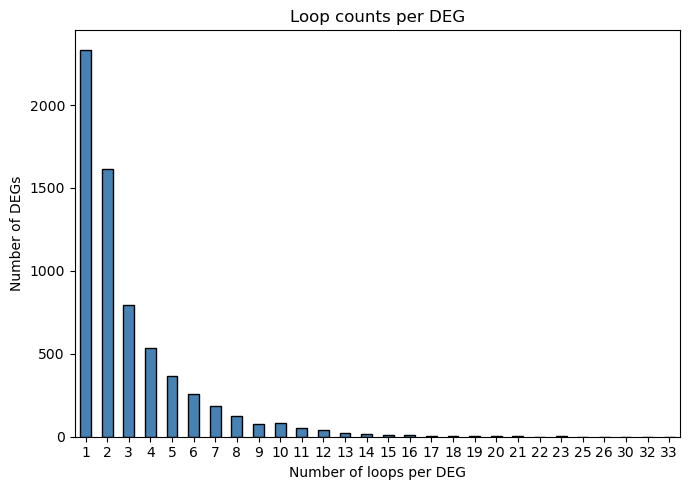

In [15]:
import matplotlib.pyplot as plt

# Count number of loops per DEG
loops_per_deg = loops_with_entrezid.groupby("gene_symbol")["Unnamed: 0"].nunique().reset_index()
loops_per_deg.columns = ["gene", "loop_count"]

# Plot distribution
plt.figure(figsize=(7,5))
loops_per_deg["loop_count"].value_counts().sort_index().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.xlabel("Number of loops per DEG")
plt.ylabel("Number of DEGs")
plt.title("Loop counts per DEG")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

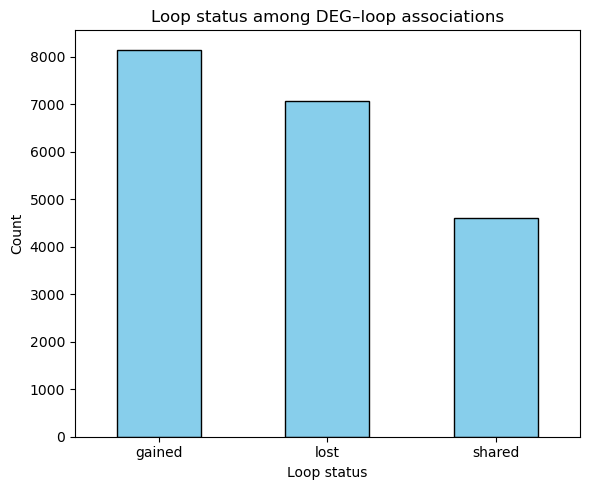

In [16]:
plt.figure(figsize=(6,5))
loops_with_entrezid["status"].value_counts().plot(
    kind="bar", color="skyblue", edgecolor="black"
)
plt.xlabel("Loop status")
plt.ylabel("Count")
plt.title("Loop status among DEG–loop associations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

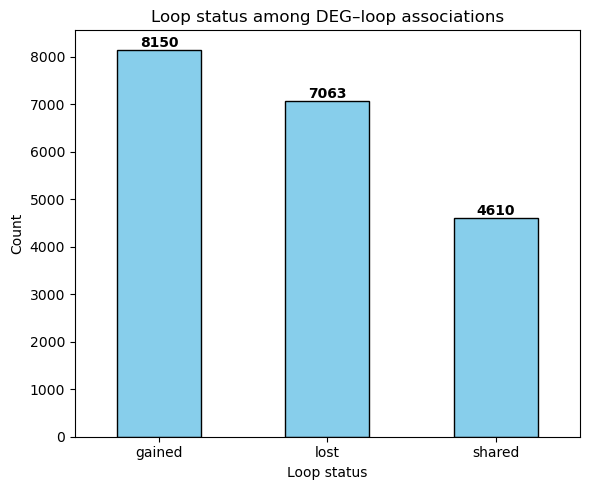

In [17]:
plt.figure(figsize=(6,5))
ax = loops_with_entrezid["status"].value_counts().plot(
    kind="bar", color="skyblue", edgecolor="black"
)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10, weight='bold'
    )

plt.xlabel("Loop status")
plt.ylabel("Count")
plt.title("Loop status among DEG–loop associations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
